In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) return false;

<IPython.core.display.Javascript object>

In [2]:
import dataset, plots, features
import pandas as pd

sp500_components = dataset.SP500.load_historical()

## Dane cenowe

Do selekcji spółek do portfela z wykorzystaniem analizy technicznej w dłuższym terminie wystarczają wartości uzyskane pod koniec sesji każdego dnia (**End-of-Day, EOD**). Ponieważ dane muszą obejmować również spółki, które już nie istnieją, aby uniknąć błędów badawczych, darmowe źródła często okazują się niewystarczające. W praktyce można przyjąć dwa podejścia:

- pobranie danych cenowych z darmowych źródeł i uzupełnienie brakujących danych profesjonalnym dostawcą

- pobranie wszystkich danych bezpośrednio od profesjonalnego dostawcy.

W tym projekcie wybrane zostało pierwsze podejście, aby zwizualizować potencjalny wpływ brakujących lub niekompletnych danych na wyniki analizy.

### Dane cenowe z Yahoo Finance

Najpopularniejszą opcją pozyskania danych cenowych jest korzystanie z [**Yahoo Finance**](https://finance.yahoo.com/?guccounter=1), np. poprzez bibliotekę [**yfinance**](https://github.com/ranaroussi/yfinance) w Pythonie, która umożliwia pobranie danych historycznych spółek wraz z cenami skorygowanymi o splity i dywidendy.

#### Uzyskanie danych z pojedynczej spółki

Poniżej przykładowe użycie tej biblioteki w celu uzyskania historii cen akcji spółki Apple (AAPL). Dane cenowe zamknięcia (**Adj Close**) są już skorygowane o dywidendy.

In [3]:
ticker = "AAPL"
dataset.YahooFinance.download_ticker(ticker, save_csv=True)
apple = dataset.YahooFinance.load_ticker(ticker)
plots.summarize_df(apple)

No new trading days since 2026-04-14.
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24776 entries, 1927-12-30 00:00:00+00:00 to 2026-04-14 00:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         11425 non-null  float64
 1   Open          11425 non-null  float64
 2   High          11425 non-null  float64
 3   Low           11425 non-null  float64
 4   Volume        11425 non-null  float64
 5   Adj_Close     11425 non-null  float64
 6   Dividends     11425 non-null  float64
 7   Stock_Splits  11425 non-null  float64
dtypes: float64(8)
memory usage: 1.7 MB
None


,Close,Open,High,Low,Volume,Adj_Close,Dividends,Stock_Splits
count,11425.00000000,11425.00000000,11425.00000000,11425.00000000,11425.00000000,11425.00000000,11425.00000000,11425.00000000
mean,30.31155386,30.29033101,30.61710978,29.98028114,308117920.02074397,29.36006104,0.00088084,0.00148796
std,60.90328871,60.85496319,61.50405711,60.24998809,333019349.77369636,60.37042321,0.01314621,0.08208521
min,0.04910700,0.04966500,0.04966500,0.04910700,0.00000000,0.03760944,0.00000000,0.00000000
25%,0.30524600,0.30535701,0.31232101,0.29910699,105224000.00000000,0.24742952,0.00000000,0.00000000
50%,0.61160702,0.60937500,0.62165201,0.59821397,197120000.00000000,0.49708629,0.00000000,0.00000000
75%,24.59499931,24.62249947,24.82749939,24.36249924,388236800.00000000,21.96901321,0.00000000,0.00000000
max,286.19000244,286.20001221,288.61999512,283.29998779,7421640800.00000000,285.92245483,0.26000000,7.00000000


,Close,Open,High,Low,Volume,Adj_Close,Dividends,Stock_Splits
Date,,,,,,,,
1927-12-30 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1928-01-03 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-13 00:00:00+00:00,259.20001221,259.73001099,260.17999268,256.66000366,35196600.00000000,259.20001221,0.00000000,0.00000000
2026-04-14 00:00:00+00:00,258.83999634,259.10000610,261.92999268,257.19009399,23315237.00000000,258.83999634,0.00000000,0.00000000


Poniższy fragment danych — dzień przed, w dniu oraz dzień po splicie akcji — pokazuje, że ceny w danych historycznych uwzględniają już split.

In [4]:
plots.YahooFinance.show_last_split(apple)

,Open,Adj_Close,Dividends,Stock_Splits
Date,,,,
2026-02-13 00:00:00+00:00,262.01000977,255.77999878,0.00000000,0.00000000
2026-02-16 00:00:00+00:00,NaN,NaN,NaN,NaN
2026-02-17 00:00:00+00:00,258.04998779,263.88000488,0.00000000,0.00000000


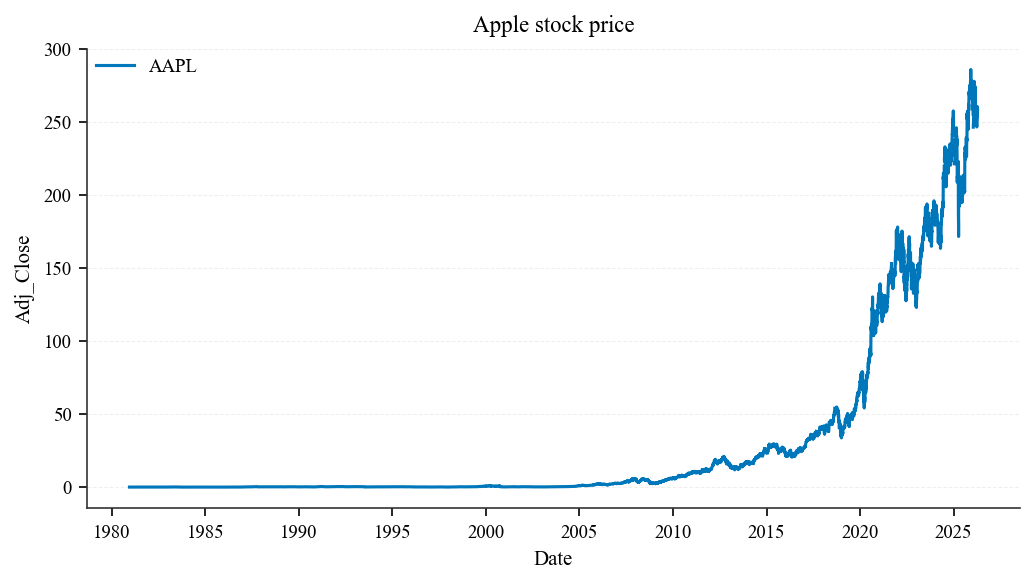

,AAPL
Date,
1927-12-30,NaN
1928-01-03,NaN
1928-01-04,NaN
1928-01-05,NaN
1928-01-06,NaN
...,...
2026-04-08,258.89999390
2026-04-09,260.48999023
2026-04-10,260.48001099


In [5]:
plots.YahooFinance.show_chart(apple, ticker, title="Apple stock price", hide_col=True)

#### Uzyskanie danych o indeksie

Na platformie Yahoo Finance dostępne są różne tickery reprezentujące indeks S&P 500, które różnią się sposobem uwzględniania dywidend:

- **SP500 (^GSPC, S&P 500)** – indeks cenowy (*price return*), uwzględniający wyłącznie zmiany cen akcji spółek wchodzących w skład indeksu
- **SP500TR (^SP500TR, S&P 500 Total Return)** – indeks dochodowy (*total return*), uwzględniający zarówno zmiany cen, jak i reinwestowane dywidendy
- **ETF (CSPX.L, iShares Core S&P 500 UCITS ETF Acc)** – fundusz ETF replikujący indeks S&P 500 w sposób fizyczny, akumulujący dywidendy (reinwestowane wewnątrz funduszu), stanowiący przybliżenie rzeczywistej stopy zwrotu inwestora

Zestawienie tych trzech instrumentów pozwala porównać:
- wpływ dywidend na długoterminową stopę zwrotu,
- różnice między indeksem teoretycznym a rzeczywistym instrumentem inwestycyjnym,
- dokładność odwzorowania indeksu przez ETF (tzw. *tracking error*).

In [6]:
ticker = "^GSPC"
dataset.YahooFinance.download_ticker(ticker, save_csv=True)
SP500 = dataset.YahooFinance.load_ticker(ticker)
plots.summarize_df(SP500)

ticker = "^SP500TR"
dataset.YahooFinance.download_ticker(ticker, save_csv=True)
SP500TR = dataset.YahooFinance.load_ticker(ticker)

ticker = "CSPX.L"
dataset.YahooFinance.download_ticker(ticker, save_csv=True)
ETF = dataset.YahooFinance.load_ticker(ticker)
plots.summarize_df(ETF)

No new trading days since 2026-04-14.
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24776 entries, 1927-12-30 00:00:00+00:00 to 2026-04-14 00:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         24687 non-null  float64
 1   Open          24687 non-null  float64
 2   High          24687 non-null  float64
 3   Low           24687 non-null  float64
 4   Volume        24687 non-null  float64
 5   Adj_Close     24687 non-null  float64
 6   Dividends     24687 non-null  float64
 7   Stock_Splits  24687 non-null  float64
dtypes: float64(8)
memory usage: 1.7 MB
None


,Close,Open,High,Low,Volume,Adj_Close,Dividends,Stock_Splits
count,24687.00000000,24687.00000000,24687.00000000,24687.00000000,24687.00000000,24687.00000000,24687.00000000,24687.00000000
mean,732.12055645,731.96978778,736.17621945,727.49069916,974935008.30396569,732.12055645,0.00000000,0.00000000
std,1256.92779427,1256.70748078,1263.36405723,1249.51922045,1692506915.47092557,1256.92779427,0.00000000,0.00000000
min,4.40000010,4.40000010,4.40000010,4.40000010,0.00000000,4.40000010,0.00000000,0.00000000
25%,24.95999908,24.95999908,24.95999908,24.95999908,1605000.00000000,24.95999908,0.00000000,0.00000000
50%,103.62999725,103.63999939,104.47000122,102.80000305,22370000.00000000,103.62999725,0.00000000,0.00000000
75%,1093.91497803,1094.03002930,1099.75000000,1085.32000732,1190100000.00000000,1093.91497803,0.00000000,0.00000000
max,6978.60009766,7002.00000000,7002.27978516,6963.45996094,11456230000.00000000,6978.60009766,0.00000000,0.00000000


No new trading days since 2026-04-14.


KeyboardInterrupt: 

Wyniki z kolumny Close i Adj Close są jednakowe.

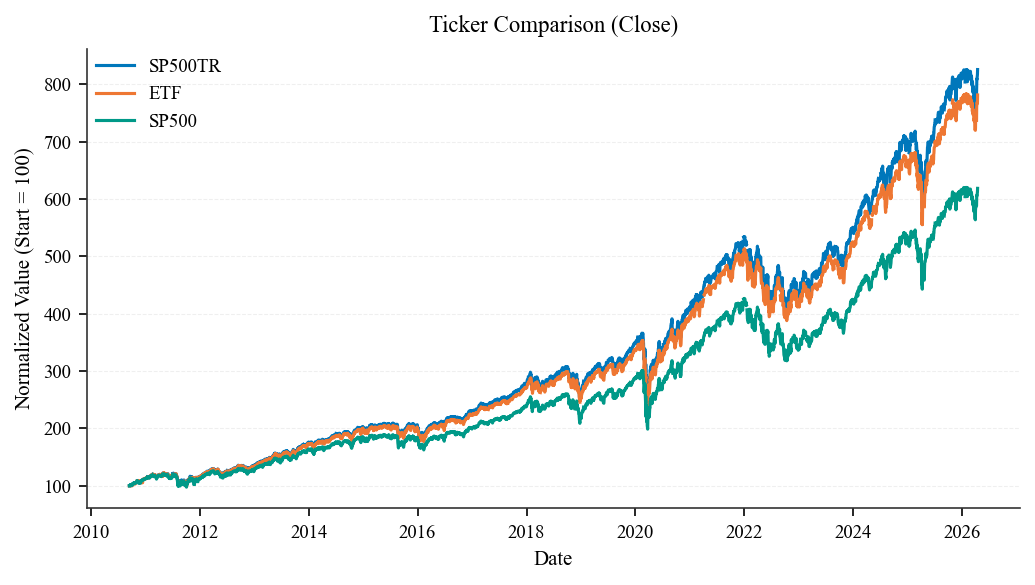

,SP500TR,ETF,SP500
Date,,,
2010-09-15,100.00000000,100.00000000,100.00000000
2010-09-16,99.98032715,100.00000000,99.96356563
2010-09-17,100.06327634,100.00000000,100.04622108
2010-09-20,101.58767217,100.00000000,101.56790382
2010-09-21,101.32926402,100.00000000,101.30748164
...,...,...,...
2026-04-08,804.51633028,760.58191980,602.87896597
2026-04-09,809.53134227,764.61168387,606.59874337
2026-04-10,808.69125779,768.28554794,605.90811791


In [ ]:
plots.YahooFinance.compare_tickers({
    "SP500": SP500,
    "SP500TR": SP500TR,
    "ETF": ETF
}, col="Close")

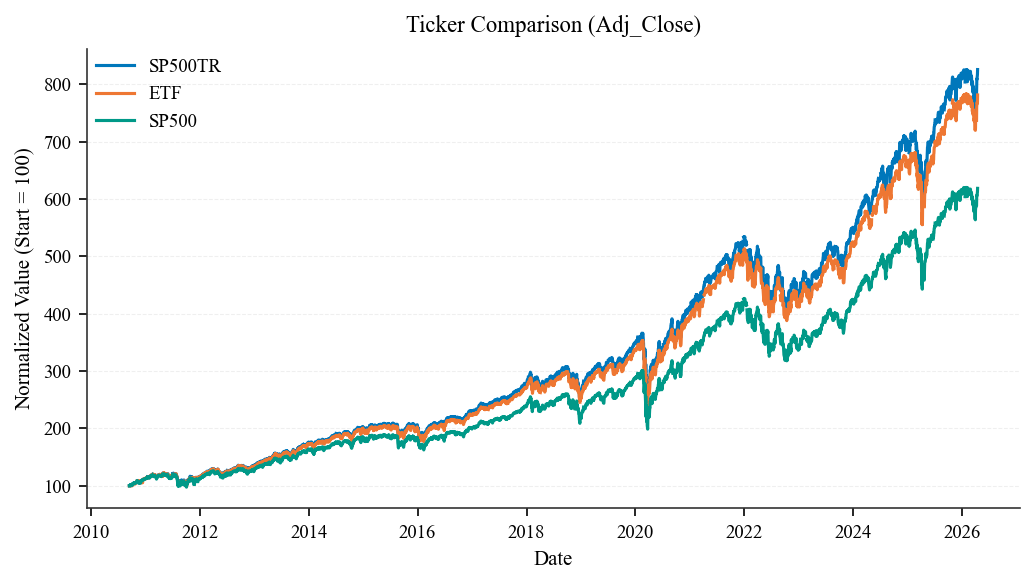

,SP500TR,ETF,SP500
Date,,,
2010-09-15,100.00000000,100.00000000,100.00000000
2010-09-16,99.98032715,100.00000000,99.96356563
2010-09-17,100.06327634,100.00000000,100.04622108
2010-09-20,101.58767217,100.00000000,101.56790382
2010-09-21,101.32926402,100.00000000,101.30748164
...,...,...,...
2026-04-08,804.51633028,760.58191980,602.87896597
2026-04-09,809.53134227,764.61168387,606.59874337
2026-04-10,808.69125779,768.28554794,605.90811791


In [ ]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "SP500": SP500,
    "ETF": ETF
}, col="Adj_Close")

Widzimy nie tylko różnicę między indeksem uwzględniającym dywidendy a tym nieuwzględniającym, ale także między indeksem total return a odpowiadającym mu ETF-em, który zwykle osiąga nieco niższe wyniki z powodu **błędu odwzorowania** (tracking error). Sam ETF nie jest więc wystarczający jako pełny benchmark historyczny, ponieważ jego najdłuższa porównywalna historia (dla ETF-u akumulującego dywidendy) rozpoczyna się dopiero około 2010 roku. Z tego powodu w analizie potrzebne są oba szeregi: **SP500TR** (długi horyzont historyczny i referencja total return) oraz **benchmark hybrydowy** (odwzorowanie realnych warunków inwestora poprzez uwzględnienie tracking error i wykorzystanie rzeczywistych notowań ETF tam, gdzie są dostępne).

#### Hybrydowy indeks S&P 500

W praktyce: SP500TR odpowiada za część historyczną (przed debiutem ETF), a hybryda zapewnia ciągłość serii i porównywalność wyników z realnym instrumentem inwestycyjnym.

Do konstrukcji hybrydowego indeksu rozważono podejścia oparte na **splicingu**, tj. łączeniu fragmentów szeregów czasowych w jedną spójną serię. Przyjęto, że w okresie dostępności ETF-u indeks hybrydowy odpowiada jego rzeczywistym notowaniom, natomiast wcześniejsze obserwacje są rekonstruowane na podstawie indeksu SP500TR.

Rozważono następujące podejścia:

1. **Proste skalowanie** — dane SP500TR są skalowane tak, aby ich wartość w punkcie łączenia była zgodna z wartością ETF-u.

2. **Bezwzględna różnica odwzorowania (tracking difference)** — w okresie wspólnym estymowana jest średnia różnica stóp zwrotu:

   $$\overline{\text{TD}} = \frac{1}{T}\sum_{t=1}^{T}(R_{\text{TR}} - R_{\text{ETF}}),$$

   która następnie koryguje historyczne stopy zwrotu:

   $$r_{\text{HYB}} = R_{\text{TR}} - \overline{\text{TD}}.$$

   Podejście to pomija jednak kumulatywny charakter błędu odwzorowania oraz jego proporcjonalność do poziomu cen.

3. **Względna różnica odwzorowania** — w okresie wspólnym estymowana jest relatywna różnica wyników ETF względem indeksu:

   $$
   TD_{annual} = \left(\frac{R_{\text{TR}}}{R_{\text{ETF}}}\right)^{\frac{252}{N}} - 1,
   $$

   gdzie $R_{\text{TR}}$ i $R_{\text{ETF}}$ oznaczają całkowite stopy zwrotu, a $N$ liczbę dni sesyjnych.

   Otrzymany parametr interpretowany jest jako średni roczny koszt odwzorowania i przekształcany do dziennego czynnika, który jest następnie kumulowany wstecznie:

   $$
   P^{adj}_t = \frac{P_t}{d^k}, \quad d = (1 + TD_{annual})^{1/252},
   $$

   gdzie $k$ oznacza liczbę dni od momentu rozpoczęcia notowań ETF.

   Tak skorygowana seria jest następnie skalowana w punkcie łączenia w celu zapewnienia ciągłości z rzeczywistymi notowaniami ETF.

Do utworzenia benchmarku przyjęto **trzecie podejście**, ponieważ pozwala ono uchwycić kumulatywny charakter błędu odwzorowania, przy jednoczesnym zachowaniu prostoty i stabilności estymacji oraz pełnej zgodności z obserwowanymi danymi ETF po dacie jego debiutu.

Loading existing benchmark from /home/michael/Documents/University/Semestr 4/Projekt indywidualny/Repo/data/processed/benchmark_2026-04-14.csv
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24687 entries, 1927-12-30 00:00:00+00:00 to 2026-04-14 00:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         24687 non-null  float64
 1   Open          24687 non-null  float64
 2   High          24687 non-null  float64
 3   Low           24687 non-null  float64
 4   Volume        24687 non-null  int64  
 5   Adj_Close     24687 non-null  float64
 6   Dividends     24687 non-null  float64
 7   Stock_Splits  24687 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 1.7 MB
None


,Close,Open,High,Low,Volume,Adj_Close,Dividends,Stock_Splits
count,24687.00000000,24687.00000000,24687.00000000,24687.00000000,24687.00000000,24687.00000000,24687.00000000,24687.00000000
mean,732.12055645,731.96978778,736.17621945,727.49069916,974935008.30396569,732.12055645,0.00000000,0.00000000
std,1256.92779427,1256.70748078,1263.36405723,1249.51922045,1692506915.47092581,1256.92779427,0.00000000,0.00000000
min,4.40000010,4.40000010,4.40000010,4.40000010,0.00000000,4.40000010,0.00000000,0.00000000
25%,24.95999908,24.95999908,24.95999908,24.95999908,1605000.00000000,24.95999908,0.00000000,0.00000000
50%,103.62999725,103.63999939,104.47000122,102.80000305,22370000.00000000,103.62999725,0.00000000,0.00000000
75%,1093.91497803,1094.03002930,1099.75000000,1085.32000732,1190100000.00000000,1093.91497803,0.00000000,0.00000000
max,6978.60009766,7002.00000000,7002.27978516,6963.45996094,11456230000.00000000,6978.60009766,0.00000000,0.00000000


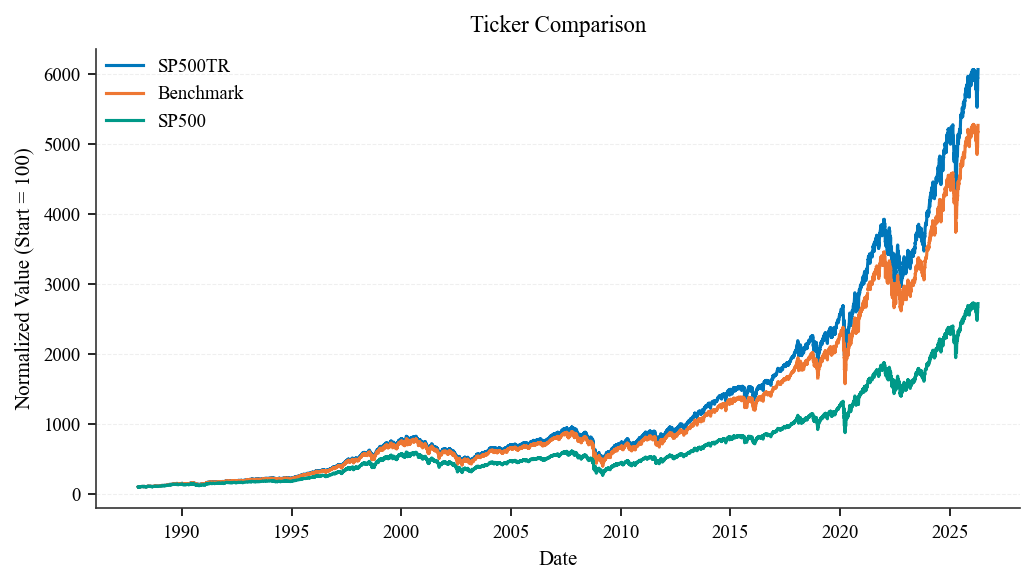

,SP500TR,Benchmark,SP500
Date,,,
1988-01-04,100.00000000,100.00000000,100.00000000
1988-01-05,101.07413488,101.07267736,101.05102853
1988-01-06,101.17569326,101.17277532,101.15261865
1988-01-07,102.02718642,102.02277269,102.00437791
1988-01-08,95.12929205,95.12380500,95.10041087
...,...,...,...
2026-04-08,5910.03085730,5126.44726397,2650.15628424
2026-04-09,5946.87147131,5153.60853668,2666.50781087
2026-04-10,5940.70015447,5178.37098490,2663.47193549


In [ ]:
benchmark = features.construct_hybrid(
    long_df=SP500TR,
    short_df=ETF,
    save_csv=True,
    cleanup_old=True
)

plots.summarize_df(SP500)

plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    # "ETF": ETF, # here shows only after 2010-09-14
    "SP500": SP500
}, hide_col=True)

Poniżej przedstawiono wizualizację dwóch okresów hybrydowego indeksu:  
- **przed debiutem ETF** – historyczne notowania odtworzone na podstawie SP500TR z uwzględnieniem tracking difference.  
- **po debiucie ETF** – hybrydowy indeks pokrywa się z ETF-em.

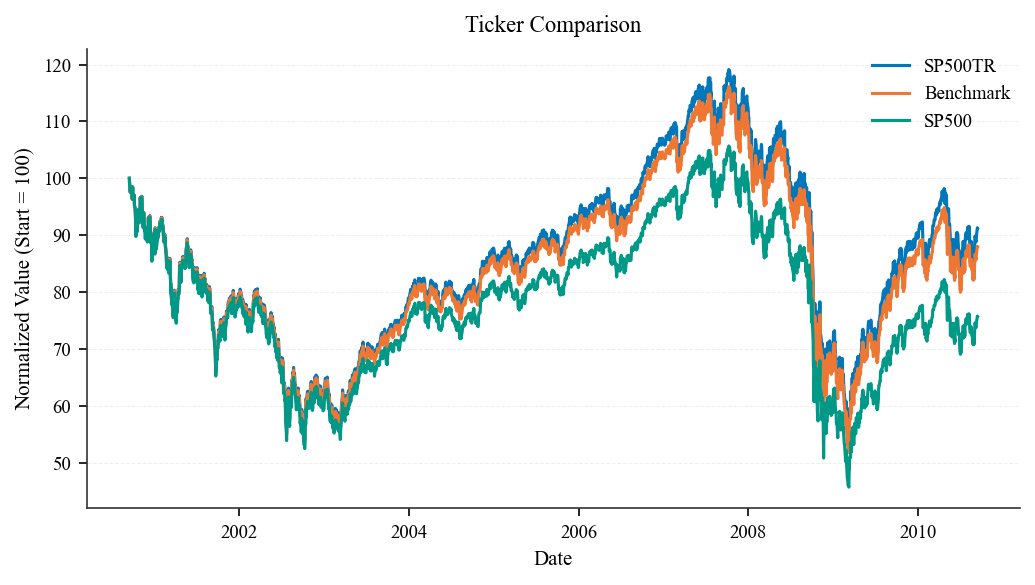

,SP500TR,Benchmark,SP500
Date,,,
2000-09-14,100.00000000,100.00000000,100.00000000
2000-09-15,98.98306332,98.98163595,98.98303453
2000-09-18,97.54650677,97.54369349,97.54468755
2000-09-19,98.58632187,98.58205700,98.58394250
2000-09-20,98.01042757,98.00477433,98.00589995
...,...,...,...
2010-09-08,89.38764760,86.21134033,74.20435276
2010-09-09,89.81993082,86.62701355,74.56292972
2010-09-10,90.25854274,87.04877842,74.92555407


In [ ]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "SP500": SP500
}, hide_col=True, start_date="2000-09-14", end_date="2010-09-14")

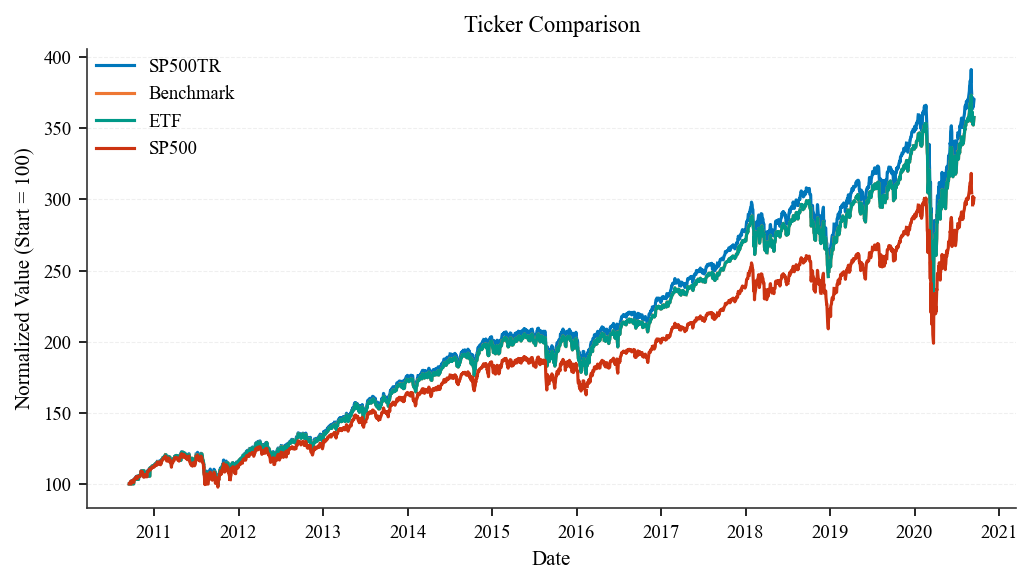

,SP500TR,Benchmark,ETF,SP500
Date,,,,
2010-09-15,100.00000000,100.00000000,100.00000000,100.00000000
2010-09-16,99.98032715,100.00000000,100.00000000,99.96356563
2010-09-17,100.06327634,100.00000000,100.00000000,100.04622108
2010-09-20,101.58767217,100.00000000,100.00000000,101.56790382
2010-09-21,101.32926402,100.00000000,100.00000000,101.30748164
...,...,...,...,...
2020-09-08,364.13432784,353.10862688,353.10862688,296.14515070
2020-09-09,371.48993491,357.72449837,357.72449837,302.11099071
2020-09-10,364.97495752,357.89197132,357.89197132,296.79843039


In [ ]:
plots.YahooFinance.compare_tickers({
    "SP500TR": SP500TR,
    "Benchmark": benchmark,
    "ETF": ETF,
    "SP500": SP500
}, hide_col=True, start_date="2010-09-14", end_date="2020-09-14")

#### S&P 500 Equal Weighted

Dla indeksu S&P 500 Equal Weighted dostępne są następujące tickery:

- **SP500EW (^SP500EW, S&P 500 Equal Weight Index)** – indeks cenowy (*price return*) równoważonej wersji S&P 500, gdzie każda spółka ma identyczny udział niezależnie od kapitalizacji
- **ETF_EW (RSP, Invesco S&P 500 Equal Weight ETF)** – fundusz ETF replikujący indeks S&P 500 z równymi wagami, akumulujący dywidendy

Na wykresie widać, że w ostatnich latach benchmark oparty na S&P 500 przewyższał ETF na S&P 500 Equal Weight. Jednak w latach przed 2018 strategia równych wag często osiągała podobne lub lepsze wyniki. Oznacza to, że relatywna efektywność podejścia equal-weight w dużej mierze zależy od siły największych spółek w indeksie.

No new trading days since 2026-04-14.
Saved Close.csv (24776 rows x 5 columns)
Saved Open.csv (24776 rows x 5 columns)
Saved High.csv (24776 rows x 5 columns)
Saved Low.csv (24776 rows x 5 columns)
Saved Volume.csv (24776 rows x 5 columns)
Saved Adj_Close.csv (24776 rows x 5 columns)
Saved Dividends.csv (24776 rows x 5 columns)
Saved Stock_Splits.csv (24776 rows x 5 columns)
No new trading days since 2026-04-14.
Saved Close.csv (24776 rows x 6 columns)
Saved Open.csv (24776 rows x 6 columns)
Saved High.csv (24776 rows x 6 columns)
Saved Low.csv (24776 rows x 6 columns)
Saved Volume.csv (24776 rows x 6 columns)
Saved Adj_Close.csv (24776 rows x 6 columns)
Saved Dividends.csv (24776 rows x 6 columns)
Saved Stock_Splits.csv (24776 rows x 6 columns)
DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24776 entries, 1927-12-30 00:00:00+00:00 to 2026-04-14 00:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  ---

,Close,Open,High,Low,Volume,Adj_Close,Dividends,Stock_Splits
count,4851.00000000,4851.00000000,4851.00000000,4851.00000000,4851.00000000,4851.00000000,4851.00000000,4851.00000000
mean,3804.89428247,3803.61648127,3827.45749607,3779.18456822,0.78334364,3804.89428247,0.00000000,0.00000000
std,1921.72661709,1920.90888967,1931.34850563,1911.25202400,54.55919569,1921.72661709,0.00000000,0.00000000
min,824.01000977,824.01000977,849.15997314,810.59997559,0.00000000,824.01000977,0.00000000,0.00000000
25%,2026.26501465,2025.92498779,2036.09997559,2013.52502441,0.00000000,2026.26501465,0.00000000,0.00000000
50%,3344.27001953,3343.43994141,3354.10009766,3326.65991211,0.00000000,3344.27001953,0.00000000,0.00000000
75%,5607.36499023,5605.80004883,5663.27978516,5560.03491211,0.00000000,5607.36499023,0.00000000,0.00000000
max,8290.63964844,8289.28027344,8306.87988281,8219.33984375,3800.00000000,8290.63964844,0.00000000,0.00000000


DataFrame summary:
<class 'pandas.DataFrame'>
DatetimeIndex: 24776 entries, 1927-12-30 00:00:00+00:00 to 2026-04-14 00:00:00+00:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         5775 non-null   float64
 1   Open          5775 non-null   float64
 2   High          5775 non-null   float64
 3   Low           5775 non-null   float64
 4   Volume        5775 non-null   float64
 5   Adj_Close     5775 non-null   float64
 6   Dividends     5775 non-null   float64
 7   Stock_Splits  5775 non-null   float64
dtypes: float64(8)
memory usage: 1.7 MB
None


,Close,Open,High,Low,Volume,Adj_Close,Dividends,Stock_Splits
count,5775.00000000,5775.00000000,5775.00000000,5775.00000000,5775.00000000,5775.00000000,5775.00000000,5775.00000000
mean,85.07790695,85.07594157,85.54337745,84.54855156,2081827.80779221,74.80519788,0.00540693,0.00069264
std,48.05466501,48.04895848,48.28854106,47.80477476,3722733.46737339,49.59752076,0.05080584,0.05263614
min,20.59000015,20.59000015,21.15999985,18.00000000,4400.00000000,15.51314640,0.00000000,0.00000000
25%,43.75999832,43.79999924,44.07124901,43.48374939,397950.00000000,32.69534874,0.00000000,0.00000000
50%,75.69999695,75.66999817,76.05999756,75.16000366,781300.00000000,62.61181641,0.00000000,0.00000000
75%,111.98500061,112.07999802,112.52999878,111.38999939,1986950.00000000,101.06523132,0.00000000,0.00000000
max,204.97000122,204.27000427,205.24000549,203.17999268,57508500.00000000,204.09623718,0.83100000,4.00000000


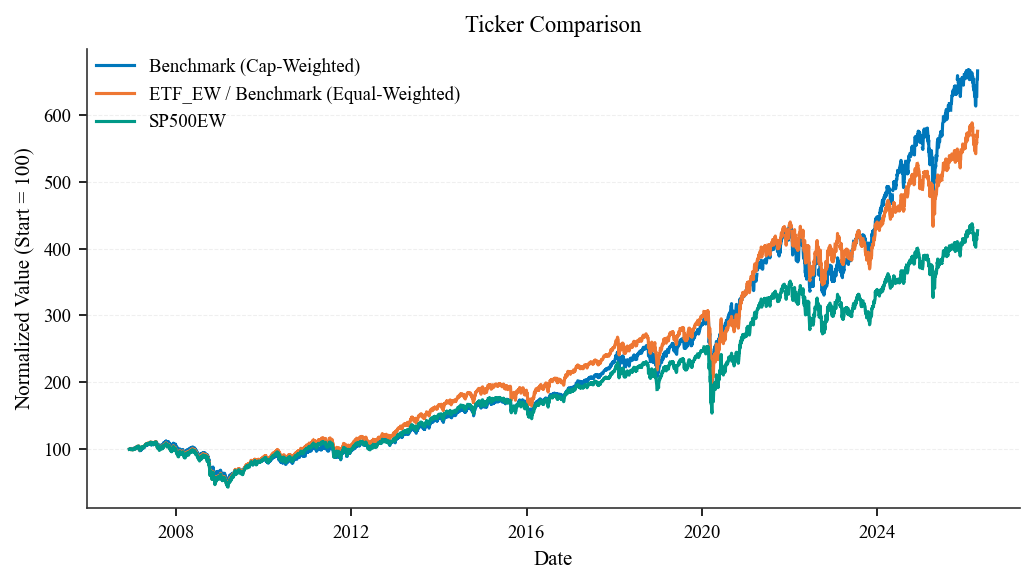

,Benchmark (Cap-Weighted),ETF_EW / Benchmark (Equal-Weighted),SP500EW
Date,,,
2006-12-08,100.00000000,100.00000000,100.00000000
2006-12-11,100.22703585,100.04201893,100.08383243
2006-12-12,100.12333029,99.89499663,99.87873422
2006-12-13,100.25730936,100.06295148,99.92091110
2006-12-14,101.13427786,100.79777730,100.74660099
...,...,...,...
2026-04-08,647.70827804,570.22268715,423.08868016
2026-04-09,651.14000771,570.56833241,423.31593202
2026-04-10,654.26865448,566.44920259,420.13602801


In [ ]:
dataset.YahooFinance.download_ticker("^SP500EW", save_csv=True)
dataset.YahooFinance.download_ticker("RSP", save_csv=True)

SP500EW = dataset.YahooFinance.load_ticker("^SP500EW")
ETF_EW = dataset.YahooFinance.load_ticker("RSP")

plots.summarize_df(SP500EW)
plots.summarize_df(ETF_EW)

plots.YahooFinance.compare_tickers({
    "Benchmark (Cap-Weighted)": benchmark,
    "ETF_EW / Benchmark (Equal-Weighted)": ETF_EW,
    "SP500EW": SP500EW,
}, hide_col=True)

Analogicznie do hybrydowego benchmarku dla S&P 500 ważonego kapitalizacją, można byłoby
skonstruować benchmark hybrydowy dla wersji equal-weighted, uwzględniając wpływ dywidend
zamiast błędu odwzorowania. W tym przypadku jednak `ETF_EW` (RSP) dysponuje najdłuższą
dostępną historią — sięgającą 2003 roku — a przedłużenie jej wstecz napotyka na istotne
ograniczenia: indeks dochodowy `SP500EWTR` nie jest dostępny w serwisie Yahoo Finance,
`SP500EW` obejmuje krótszy okres, natomiast zastosowanie benchmarku cap-weighted jako
substytutu zniekształciłoby charakterystykę strategii equal-weighted. Z tego powodu
`benchmark_ew` ograniczony jest do okresu dostępności `ETF_EW`, a porównanie obu podejść
prowadzone jest na wspólnym horyzoncie czasowym.

In [ ]:
benchmark_ew = SP500EW

#### Uzyskanie danych pojedyńczych spółek

In [ ]:
tickers = dataset.tickers_from_sp500_components(sp500_components)

dataset.YahooFinance.download(
    tickers,
    save_csv=True,
 )
yf_data: dict[str, pd.DataFrame] = dataset.YahooFinance.load()
for column_name, frame in yf_data.items():
    if frame.empty:
        print(f"{column_name}: empty")
    else:
        print(f"{column_name}: {frame.shape}, {frame.index.min().date()} -> {frame.index.max().date()}")

Number of unique tickers extracted: 1194
No new trading days since 2026-04-14.


$BMET: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$BKB: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$AWE: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$BRCM: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$ARC: possibly delisted; no timezone found
$AVP: possibly delisted; no timezone found
$BF.B: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$AV: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$AW: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$ARNC: possibly delisted; no timezone found
$CBS: possibly delisted; no timezone found
$BHGE: possibly delisted; no timezone found
$AGC: possibly delisted; no timezone found
$BGG: possibly delisted; no timezone found
$ASN: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$AMCC: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$ADS: possi

$CDAY: possibly delisted; no timezone found
$CRR: possibly delisted; no timezone found
$CNW: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$DALRQ: possibly delisted; no timezone found
$DTV: possibly delisted; no timezone found
$ENDP: possibly delisted; no timezone found
$CHK: possibly delisted; no timezone found
$DAY: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14) (Yahoo error = "No data found, symbol may be delisted")
$CTXS: possibly delisted; no timezone found
$EKDKQ: possibly delisted; no timezone found
$DWDP: possibly delisted; no timezone found
$DCNAQ: possibly delisted; no timezone found
$DNR: possibly delisted; no timezone found
$DPHIQ: possibly delisted; no timezone found
$CITGQ: possibly delisted; no timezone found
$EOP: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$DISH: possibly delisted; no timezone found
$COG: possibly delisted; no timezone found
$CVH: possibly delisted; no price data found  (1d 1927-0

$GAPTQ: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$HSP: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$HNZ: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$HRS: possibly delisted; no timezone found
$FI: possibly delisted; no timezone found
$HCR: possibly delisted; no timezone found
$GMCR: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$HFS: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$FTL.A: possibly delisted; no timezone found
$IPG: possibly delisted; no timezone found
$GWF: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$FBO: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$FWLT: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$FSL: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$HBOC: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$HCBK: possibly del

$MYG: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$KSE: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$KORS: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$K: possibly delisted; no timezone found
$MMC: possibly delisted; no timezone found
$NVLS: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$LXK: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$LLX: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$MNK: possibly delisted; no timezone found
$NAE: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$MWW: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$NLC: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$MJN: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$LOR: possibly delisted; no timezone found
$MON: possibly delisted; no timezone found
$NAV: possibly delisted; 

$PMCS: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$SLR: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$PEL: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$PNU: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$ODP: possibly delisted; no timezone found
$QTRN: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$QLGC: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$RDC: possibly delisted; no timezone found
$SFA: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$RSHCQ: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$RHT: possibly delisted; no timezone found
$RBK: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$SK: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$ROH: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$PVT: possibly delisted; no tim

$VTSS: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$XLNX: possibly delisted; no timezone found
$USHC: possibly delisted; no timezone found
$TSG: possibly delisted; no timezone found
$WWY: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$USW: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$UMG: possibly delisted; no timezone found
$YRCW: possibly delisted; no timezone found
$SUNEQ: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$SYMC: possibly delisted; no timezone found
$TMK: possibly delisted; no timezone found
$UN: possibly delisted; no timezone found
$WFT: possibly delisted; no timezone found
$WLA: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$WAMUQ: possibly delisted; no price data found  (1d 1927-05-09 -> 2026-04-14)
$WBA: possibly delisted; no timezone found
$X: possibly delisted; no timezone found
$XL: possibly delisted; no timezone found
$SWY: possibly delisted

Saved Close.csv (24776 rows x 1199 columns)
Saved Open.csv (24776 rows x 1199 columns)
Saved High.csv (24776 rows x 1199 columns)
Saved Low.csv (24776 rows x 1199 columns)
Saved Volume.csv (24776 rows x 1199 columns)
Saved Adj_Close.csv (24776 rows x 1199 columns)
Saved Dividends.csv (24776 rows x 825 columns)
Saved Stock_Splits.csv (24776 rows x 825 columns)
Close: (24776, 1199), 1927-12-30 -> 2026-04-14
Open: (24776, 1199), 1927-12-30 -> 2026-04-14
High: (24776, 1199), 1927-12-30 -> 2026-04-14
Low: (24776, 1199), 1927-12-30 -> 2026-04-14
Volume: (24776, 1199), 1927-12-30 -> 2026-04-14
Adj_Close: (24776, 1199), 1927-12-30 -> 2026-04-14
Dividends: (24776, 825), 1927-12-30 -> 2026-04-14
Stock_Splits: (24776, 825), 1927-12-30 -> 2026-04-14


#### Ile danych brakuje?

Na poniższym wykresie widać, że w 1996 dane z Yahoo Finance pokrywają tylko 38%. Przy wyższym pokryciu można byłoby zastosować imputację brakujących danych, jednak jest ono na tyle małe, że konieczne będzie skorzystanie z dostawców danych, pokrywających spółki, które już nie są notowane.

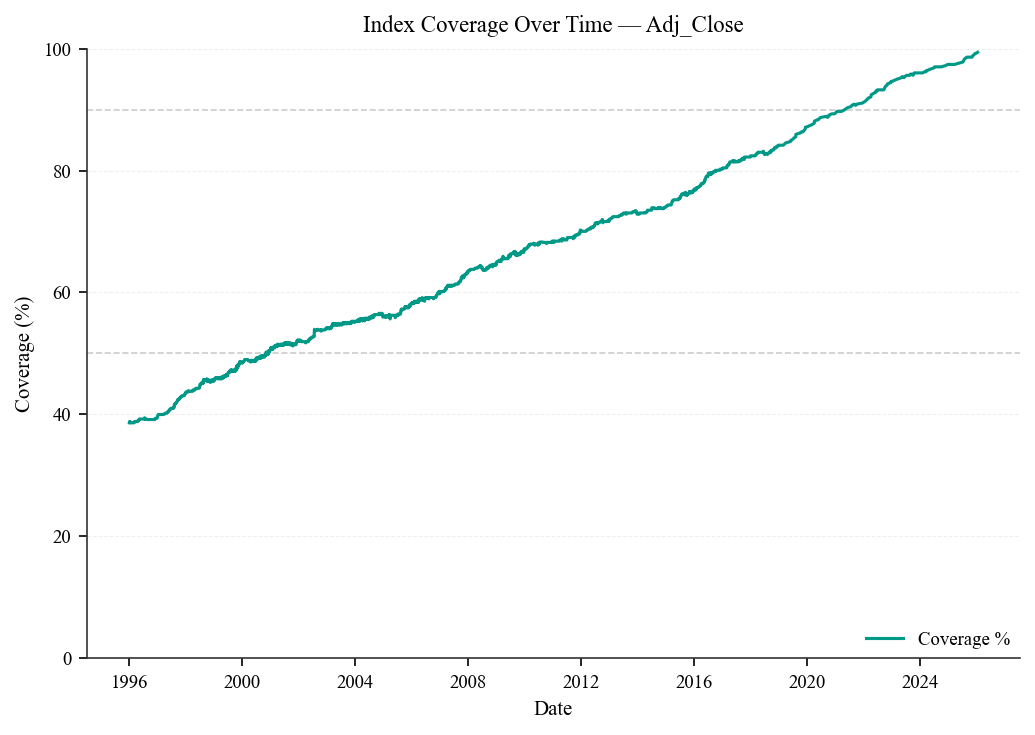

Missing ticker coverage periods:
- AABA:
  missing from 1999-12-08 to 2017-06-16
- AAL:
  missing from 1996-01-02 to 1997-01-13
- AAMRQ:
  missing from 1996-01-02 to 2003-03-10
- ABC:
  missing from 2001-08-30 to 2023-08-25
- ABI:
  missing from 1996-01-02 to 2008-11-20
- ABKFQ:
  missing from 2000-12-11 to 2008-06-10
- ABMD:
  missing from 2018-05-31 to 2022-12-19
- ABS:
  missing from 1996-01-02 to 2006-05-31
- ABX:
  missing from 1996-01-02 to 2002-07-18
- ACAS:
  missing from 2007-07-09 to 2009-03-02
- ACKH:
  missing from 1996-01-02 to 2000-11-08
- ACS:
  missing from 2004-04-02 to 2010-02-02
- ACV:
  missing from 1996-01-02 to 2006-11-16
- ADCT:
  missing from 1999-08-02 to 2007-06-26
- ADS:
  missing from 2013-12-23 to 2020-05-22
- ADT:
  missing from 2012-10-02 to 2016-04-28
- AEE:
  missing from 1996-01-02 to 1997-12-31
- AET:
  missing from 1996-01-02 to 2018-11-28
- AFS.A:
  missing from 1998-04-08 to 2000-11-29
- AGC:
  missing from 1996-01-02 to 2001-08-20
- AGN:
  missing

,available,missing,not_downloaded,total,coverage_pct
count,2705.00000000,2705.00000000,2705.00000000,2705.00000000,2705.00000000
mean,312.50055453,184.24879852,0.00000000,496.74935305,62.77348877
std,72.76614649,67.95654165,0.00000000,5.16624733,14.02972198
min,188.00000000,3.00000000,0.00000000,487.00000000,38.60369610
25%,255.00000000,133.00000000,0.00000000,494.00000000,51.51515152
50%,313.00000000,184.00000000,0.00000000,497.00000000,62.97786720
75%,364.00000000,240.00000000,0.00000000,499.00000000,73.23943662
max,500.00000000,299.00000000,0.00000000,507.00000000,99.40357853


,available,missing,not_downloaded,total,coverage_pct
1996-01-02,188,299,0,487,38.60369610
1996-01-03,189,298,0,487,38.80903491
2025-12-22,499,4,0,503,99.20477137
2026-01-14,500,3,0,503,99.40357853


In [ ]:
coverage_df = plots.coverage_over_time(yf_data, sp500_components)
plots.summarize_df(coverage_df)